In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

## Lectura de datos

La lectura local se mantiene exactamente igual que en el notebook original.

In [2]:
data = pd.read_excel('BaseEI.xlsx')
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   mar_emp               10000 non-null  int64  
 1   DiasMora              10000 non-null  int64  
 2   Factor                10000 non-null  float64
 3   STOTAL                10000 non-null  float64
 4   df_Life_M             10000 non-null  int64  
 5   utilizacion           10000 non-null  float64
 6   prom_saldo_6m         10000 non-null  float64
 7   prom_diasmora_6m      10000 non-null  float64
 8   prom_df_life_M_6m     10000 non-null  float64
 9   prom_utilizacion_6m   10000 non-null  float64
 10  prom_saldo_12m        10000 non-null  float64
 11  prom_diasmora_12m     10000 non-null  float64
 12  prom_df_life_M_12m    10000 non-null  float64
 13  prom_utilizacion_12m  10000 non-null  float64
dtypes: float64(11), int64(3)
memory usage: 1.1 MB


## Creación de variables auxiliares

EI se calcula únicamente para evaluar el error monetario. No se debe usar como variable explicativa porque se construye directamente con Factor y STOTAL, por lo que generaría fuga de información.

log_STOTAL se calcula ya que puede ayudar a representar mejor la escala del saldo.

In [3]:
EI = data['Factor']*data['STOTAL']
data['EI'] = EI
data['log_STOTAL'] = np.log1p(data['STOTAL'])
data

,mar_emp,DiasMora,Factor,STOTAL,df_Life_M,utilizacion,prom_saldo_6m,prom_diasmora_6m,prom_df_life_M_6m,prom_utilizacion_6m,prom_saldo_12m,prom_diasmora_12m,prom_df_life_M_12m,prom_utilizacion_12m,EI,log_STOTAL
0,0,0,0.359527,1121.00,131,0.004484,1.105915e+03,0.0,128.5,0.004424,1.088168e+03,0.0,125.5,0.004353,403.03,7.022868
1,0,0,0.357444,1781.20,132,0.008906,1.756715e+03,0.0,129.5,0.008784,1.728425e+03,0.0,126.5,0.008642,636.68,7.485604
2,0,0,0.882939,26996677.02,74,0.067200,2.794959e+07,0.0,71.5,0.069572,2.902751e+07,0.0,68.5,0.081019,23836410.89,17.111224
3,0,0,0.895963,26604235.70,75,0.066223,2.757113e+07,0.0,72.5,0.068630,2.866305e+07,0.0,69.5,0.077876,23836410.89,17.096581
4,0,0,0.939088,25382522.19,78,0.063182,2.639019e+07,0.0,75.5,0.065690,2.753865e+07,0.0,72.5,0.068549,23836410.89,17.049571
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,1,0,1.042386,3062368.16,20,1.020789,2.422729e+06,0.0,17.5,0.807576,2.214383e+06,0.0,14.5,0.738128,3192170.24,14.934699
9996,1,0,1.084644,2166267.62,18,0.984667,2.112829e+06,0.0,15.5,0.960377,1.997039e+06,0.0,12.5,0.907745,2349630.20,14.588517
9997,1,0,0.873374,2987738.63,17,0.995913,2.095391e+06,0.0,16.0,0.698464,1.975373e+06,0.0,12.6,0.658458,2609413.14,14.910028
9998,1,0,2.138089,1220441.71,19,0.406814,2.081932e+06,0.0,17.0,0.693977,2.202870e+06,0.0,15.5,0.734290,2609413.14,14.014724


## Separación de variables y conjuntos de entrenamiento, validación y prueba

Se predice Factor. Para entrenar el modelo se elimina EI, porque contiene información directa de la variable objetivo.



In [4]:
X = data.drop(['Factor'], axis=1)
y = data['Factor']

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42)

X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42)

X_train_model = X_train.drop(['EI'], axis=1)
X_val_model = X_val.drop(['EI'], axis=1)
X_test_model = X_test.drop(['EI'], axis=1)

print('Train:', X_train_model.shape)
print('Validación:', X_val_model.shape)
print('Test:', X_test_model.shape)

Train: (7000, 14)
Validación: (1500, 14)
Test: (1500, 14)


## Modelo base

Antes del grid search, se entrena un modelo base para tener una referencia inicial de desempeño.

In [5]:
xgb_model = xgb.XGBRegressor(
    objective="reg:squarederror",
    n_estimators=500,
    learning_rate=0.03,
    max_depth=3,
    min_child_weight=10,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    reg_alpha=0.0,
    random_state=42,
    n_jobs=-1)

xgb_model.fit(X_train_model, y_train)

y_val_pred_base = xgb_model.predict(X_val_model)
y_val_pred_base = np.maximum(y_val_pred_base, 0)

mae = mean_absolute_error(y_val, y_val_pred_base)
rmse = np.sqrt(mean_squared_error(y_val, y_val_pred_base))
r2 = r2_score(y_val, y_val_pred_base)

print("Métricas del modelo base en validación")
print("MAE Factor:", mae)
print("RMSE Factor:", rmse)
print("R2 Factor:", r2)

Métricas del modelo base en validación
MAE Factor: 0.1600338482486379
RMSE Factor: 0.27724300453681777
R2 Factor: 0.2405004263794679


## Grid Search de hiperparámetros

Se usa GridSearchCV con validación cruzada de 3 particiones.

El criterio principal de selección es el RMSE de `Factor`, pero también se guardan MAE y R2 de validación cruzada.

In [8]:
RANDOM_STATE = 42

xgb_base = xgb.XGBRegressor(
    objective="reg:squarederror",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

param_grid = {
    "n_estimators": [300, 500],
    "learning_rate": [0.03, 0.05],
    "max_depth": [3, 4],
    "min_child_weight": [10, 20],
    "subsample": [0.8],
    "colsample_bytree": [0.8],
    "gamma": [0],
    "reg_lambda": [1],
    "reg_alpha": [0.0, 0.1]
}

cv = KFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

scoring = {
    "RMSE_Factor": "neg_root_mean_squared_error",
    "MAE_Factor": "neg_mean_absolute_error",
    "R2_Factor": "r2"
}

search = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid,
    scoring=scoring,
    refit="RMSE_Factor",
    cv=cv,
    verbose=1,
    n_jobs=-1,
    return_train_score=True
)

search.fit(X_train_model, y_train)

print("Mejores hiperparámetros:")
print(search.best_params_)
print("Mejor RMSE CV:", -search.best_score_)
print("Mejor modelo:")
print(search.best_estimator_)

Fitting 3 folds for each of 32 candidates, totalling 96 fits
Mejores hiperparámetros:
{'colsample_bytree': 0.8, 'gamma': 0, 'learning_rate': 0.03, 'max_depth': 4, 'min_child_weight': 20, 'n_estimators': 300, 'reg_alpha': 0.0, 'reg_lambda': 1, 'subsample': 0.8}
Mejor RMSE CV: 0.2696635434771919
Mejor modelo:
XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=0, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.03, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
             max_leaves=None, min_child_weight=20, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
      

## Resultados de la búsqueda

Se muestran las mejores combinaciones ordenadas por RMSE promedio en validación cruzada.

In [9]:
cv_results = pd.DataFrame(search.cv_results_)

cols_resultados = [
    'mean_test_RMSE_Factor',
    'std_test_RMSE_Factor',
    'mean_test_MAE_Factor',
    'mean_test_R2_Factor',
    'params'
]

resultados_grid = cv_results[cols_resultados].copy()
resultados_grid['RMSE_CV'] = -resultados_grid['mean_test_RMSE_Factor']
resultados_grid['MAE_CV'] = -resultados_grid['mean_test_MAE_Factor']
resultados_grid['R2_CV'] = resultados_grid['mean_test_R2_Factor']

resultados_grid = resultados_grid[['RMSE_CV', 'MAE_CV', 'R2_CV', 'params']]
resultados_grid.sort_values('RMSE_CV').head(10)

,RMSE_CV,MAE_CV,R2_CV,params
12,0.269664,0.156810,0.219771,"{'colsample_bytree': 0.8, 'gamma': 0, 'learnin..."
13,0.269841,0.156865,0.218734,"{'colsample_bytree': 0.8, 'gamma': 0, 'learnin..."
5,0.270577,0.157079,0.214557,"{'colsample_bytree': 0.8, 'gamma': 0, 'learnin..."
8,0.270646,0.156446,0.214035,"{'colsample_bytree': 0.8, 'gamma': 0, 'learnin..."
9,0.270648,0.156475,0.214002,"{'colsample_bytree': 0.8, 'gamma': 0, 'learnin..."
14,0.270727,0.157825,0.213426,"{'colsample_bytree': 0.8, 'gamma': 0, 'learnin..."
15,0.270824,0.157755,0.212921,"{'colsample_bytree': 0.8, 'gamma': 0, 'learnin..."
1,0.270955,0.156796,0.212302,"{'colsample_bytree': 0.8, 'gamma': 0, 'learnin..."
4,0.270966,0.157166,0.212294,"{'colsample_bytree': 0.8, 'gamma': 0, 'learnin..."
0,0.271001,0.156770,0.212021,"{'colsample_bytree': 0.8, 'gamma': 0, 'learnin..."


## Evaluación del mejor modelo en validación

Primero se evalúa el mejor modelo encontrado por GridSearchCV sobre el conjunto de validación. Se reportan métricas tanto para Factor como para EI.

In [10]:
best_xgb_cv = search.best_estimator_

y_val_pred = best_xgb_cv.predict(X_val_model)
y_val_pred = np.maximum(y_val_pred, 0)

val_pred_data = pd.DataFrame({
    'Factor_true': y_val,
    'Factor_pred': y_val_pred,
    'STOTAL_true': X_val['STOTAL'],
    'EI_true': X_val['EI']
})

val_pred_data['EI_pred'] = val_pred_data['Factor_pred']*val_pred_data['STOTAL_true']
val_pred_data['error_factor'] = val_pred_data['Factor_pred'] - val_pred_data['Factor_true']
val_pred_data['error_monetario'] = val_pred_data['EI_pred'] - val_pred_data['EI_true']
val_pred_data['error_monetario_abs'] = val_pred_data['error_monetario'].abs()

metricas_val = pd.DataFrame({
    'Métrica': ['MAE', 'RMSE', 'R2'],
    'Factor': [
        mean_absolute_error(val_pred_data['Factor_true'], val_pred_data['Factor_pred']),
        np.sqrt(mean_squared_error(val_pred_data['Factor_true'], val_pred_data['Factor_pred'])),
        r2_score(val_pred_data['Factor_true'], val_pred_data['Factor_pred'])
    ],
    'EI': [
        mean_absolute_error(val_pred_data['EI_true'], val_pred_data['EI_pred']),
        np.sqrt(mean_squared_error(val_pred_data['EI_true'], val_pred_data['EI_pred'])),
        r2_score(val_pred_data['EI_true'], val_pred_data['EI_pred'])
    ]
})

metricas_val

,Métrica,Factor,EI
0,MAE,0.160133,174137.583964
1,RMSE,0.276931,606509.070622
2,R2,0.242208,0.871313


## Entrenamiento final del mejor modelo

Una vez seleccionados los hiperparámetros, se reentrena el modelo usando entrenamiento + validación.

In [11]:
X_train_val_model = pd.concat([X_train_model, X_val_model], axis=0)
y_train_val = pd.concat([y_train, y_val], axis=0)

best_xgb = xgb.XGBRegressor(
    objective="reg:squarederror",
    random_state=RANDOM_STATE,
    n_jobs=-1,
    **search.best_params_
)

best_xgb.fit(X_train_val_model, y_train_val)

best_pred = best_xgb.predict(X_test_model)
best_pred = np.maximum(best_pred, 0)

mae = mean_absolute_error(y_test, best_pred)
rmse = np.sqrt(mean_squared_error(y_test, best_pred))
r2 = r2_score(y_test, best_pred)

print("Métricas finales en TEST para Factor")
print("MAE Factor:", mae)
print("RMSE Factor:", rmse)
print("R2 Factor:", r2)

Métricas finales en TEST para Factor
MAE Factor: 0.16315299525047883
RMSE Factor: 0.285903957368156
R2 Factor: 0.22080453002730416


## Tabla de predicciones finales

Se calcula la EI predicha multiplicando `Factor_pred` por `STOTAL`. Esta tabla permite revisar directamente el error en unidades monetarias.

In [12]:
best_pred_data = pd.DataFrame({
    'Factor_true': y_test,
    'Factor_pred': best_pred,
    'STOTAL_true': X_test['STOTAL'],
    'EI_true': X_test['EI']
})

best_pred_data['EI_pred'] = best_pred_data['Factor_pred']*best_pred_data['STOTAL_true']
best_pred_data['error_factor'] = best_pred_data['Factor_pred'] - best_pred_data['Factor_true']
best_pred_data['error_monetario'] = best_pred_data['EI_pred'] - best_pred_data['EI_true']
best_pred_data['error_monetario_abs'] = best_pred_data['error_monetario'].abs()

best_pred_data

,Factor_true,Factor_pred,STOTAL_true,EI_true,EI_pred,error_factor,error_monetario,error_monetario_abs
2697,1.009478,1.011707,63715.83,64319.72,6.446176e+04,0.002229,142.043117,142.043117
6871,1.027333,0.991744,50690.79,52076.31,5.027227e+04,-0.035589,-1804.036169,1804.036169
3487,0.181787,0.906925,11203.38,2036.63,1.016062e+04,0.725137,8123.990318,8123.990318
92,0.994824,0.874388,8191484.18,8149087.71,7.162532e+06,-0.120437,-986555.338186,986555.338186
9537,1.024105,1.083803,60239.76,61691.85,6.528803e+04,0.059698,3596.178900,3596.178900
...,...,...,...,...,...,...,...,...
9974,0.841720,1.057654,819637.75,689905.45,8.668935e+05,0.215934,176988.006955,176988.006955
7025,1.023404,1.025434,102940.27,105349.45,1.055584e+05,0.002030,208.992324,208.992324
3542,1.138076,1.049505,62096.32,70670.33,6.517041e+04,-0.088571,-5499.924565,5499.924565
5865,0.884405,1.090221,63853.44,56472.32,6.961434e+04,0.205815,13142.021401,13142.021401


## Métricas finales de evaluación



In [13]:
metricas_test = pd.DataFrame({
    'Métrica': ['MAE', 'RMSE', 'R2'],
    'Factor': [
        mean_absolute_error(best_pred_data['Factor_true'], best_pred_data['Factor_pred']),
        np.sqrt(mean_squared_error(best_pred_data['Factor_true'], best_pred_data['Factor_pred'])),
        r2_score(best_pred_data['Factor_true'], best_pred_data['Factor_pred'])
    ],
    'EI': [
        mean_absolute_error(best_pred_data['EI_true'], best_pred_data['EI_pred']),
        np.sqrt(mean_squared_error(best_pred_data['EI_true'], best_pred_data['EI_pred'])),
        r2_score(best_pred_data['EI_true'], best_pred_data['EI_pred'])
    ]
})

metricas_test

,Métrica,Factor,EI
0,MAE,0.163153,165012.618784
1,RMSE,0.285904,637063.944152
2,R2,0.220805,0.880512


## Gráficas

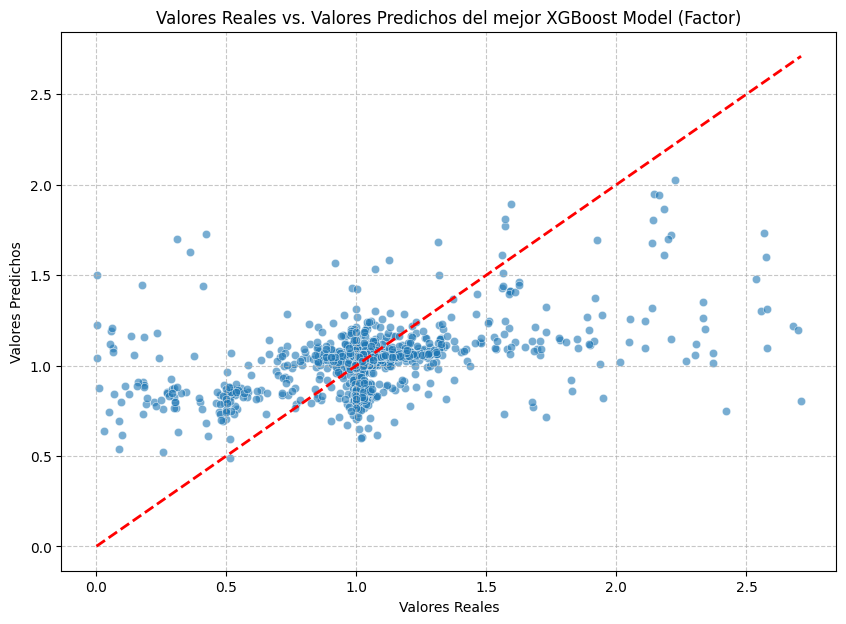

In [14]:
plt.figure(figsize=(10, 7))
sns.scatterplot(x=best_pred_data['Factor_true'], y=best_pred_data['Factor_pred'], alpha=0.6)
lim_min = min(best_pred_data['Factor_true'].min(), best_pred_data['Factor_pred'].min())
lim_max = max(best_pred_data['Factor_true'].max(), best_pred_data['Factor_pred'].max())
plt.plot([lim_min, lim_max], [lim_min, lim_max], 'r--', lw=2)
plt.xlabel('Valores Reales')
plt.ylabel('Valores Predichos')
plt.title('Valores Reales vs. Valores Predichos del mejor XGBoost Model (Factor)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

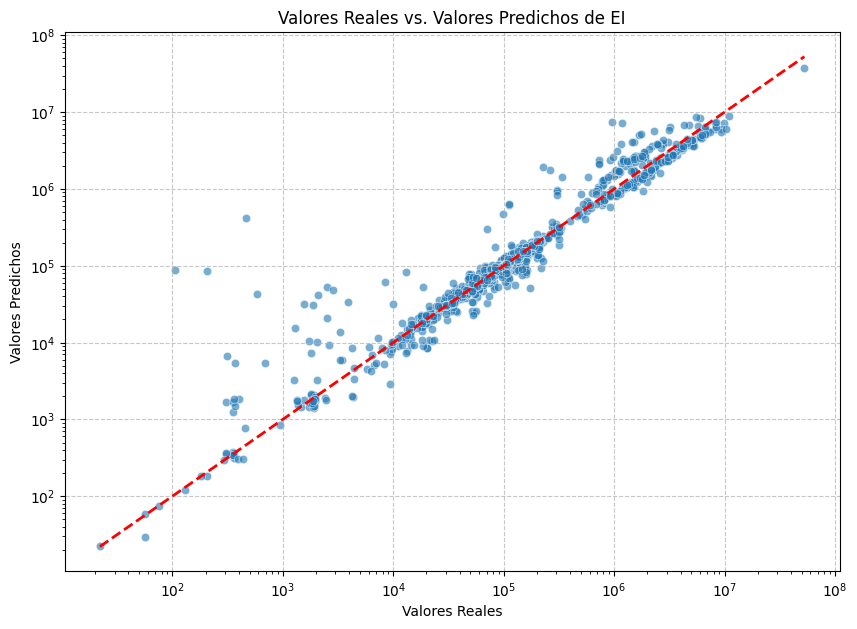

In [15]:
plot_ei = best_pred_data[(best_pred_data['EI_true'] > 0) & (best_pred_data['EI_pred'] > 0)].copy()

plt.figure(figsize=(10, 7))
sns.scatterplot(x=plot_ei['EI_true'], y=plot_ei['EI_pred'], alpha=0.6)
lim_min = min(plot_ei['EI_true'].min(), plot_ei['EI_pred'].min())
lim_max = max(plot_ei['EI_true'].max(), plot_ei['EI_pred'].max())
plt.plot([lim_min, lim_max], [lim_min, lim_max], 'r--', lw=2)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Valores Reales')
plt.ylabel('Valores Predichos')
plt.title('Valores Reales vs. Valores Predichos de EI')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

## Gráfica: error monetario

El error monetario se define como:

$Error = EI_{pred} - EI_{true}$


Valores positivos indican sobreestimación de la exposición; valores negativos indican subestimación.

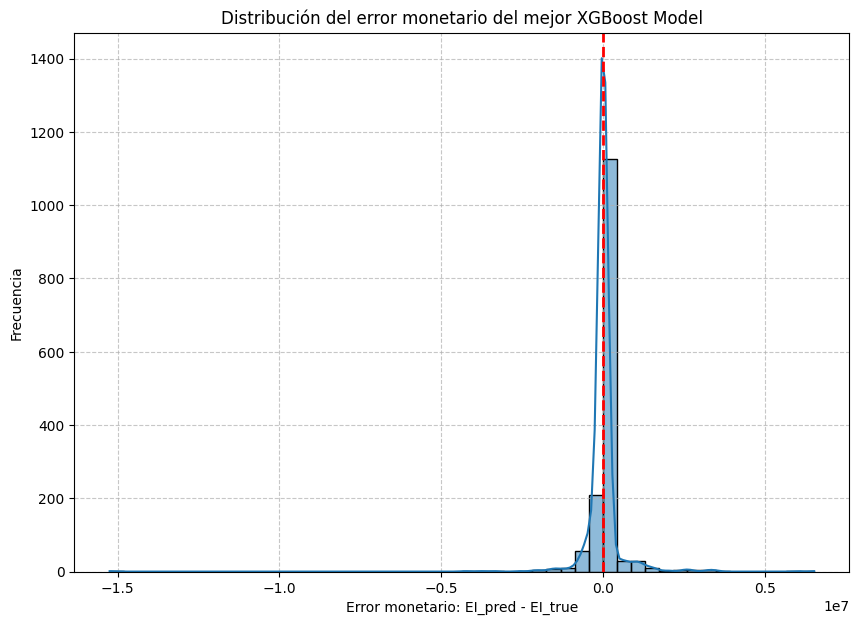

Error monetario medio: -1703.9216823069628
Error monetario absoluto medio: 165012.61878376693
Mediana del error monetario absoluto: 6293.8588078713365
Percentil 95 del error monetario absoluto: 903137.8766039703


In [16]:
plt.figure(figsize=(10, 7))
sns.histplot(best_pred_data['error_monetario'], bins=50, kde=True)
plt.axvline(0, color='red', linestyle='--', lw=2)
plt.xlabel('Error monetario: EI_pred - EI_true')
plt.ylabel('Frecuencia')
plt.title('Distribución del error monetario del mejor XGBoost Model')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

print('Error monetario medio:', best_pred_data['error_monetario'].mean())
print('Error monetario absoluto medio:', best_pred_data['error_monetario_abs'].mean())
print('Mediana del error monetario absoluto:', best_pred_data['error_monetario_abs'].median())
print('Percentil 95 del error monetario absoluto:', best_pred_data['error_monetario_abs'].quantile(0.95))

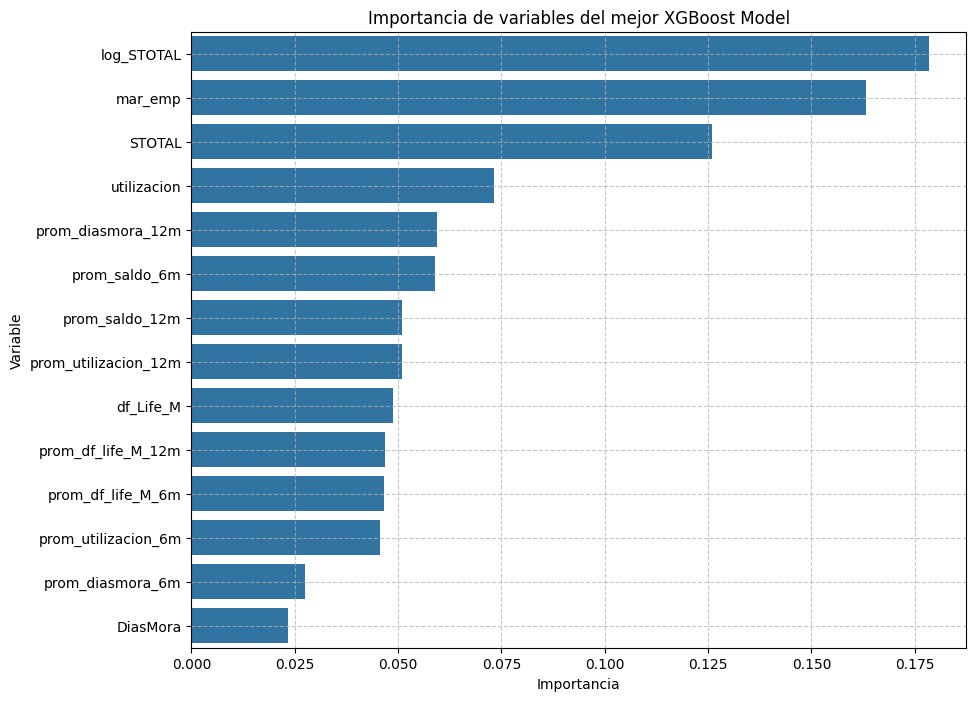

,feature,importance
13,log_STOTAL,0.178545
0,mar_emp,0.163083
2,STOTAL,0.125944
4,utilizacion,0.073278
10,prom_diasmora_12m,0.059477
5,prom_saldo_6m,0.058809
9,prom_saldo_12m,0.051052
12,prom_utilizacion_12m,0.050880
3,df_Life_M,0.048752
11,prom_df_life_M_12m,0.046907


In [17]:
importancias = pd.DataFrame({
    'feature': X_train_val_model.columns,
    'importance': best_xgb.feature_importances_
})

importancias = importancias.sort_values('importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(data=importancias.head(20), x='importance', y='feature')
plt.xlabel('Importancia')
plt.ylabel('Variable')
plt.title('Importancia de variables del mejor XGBoost Model')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

importancias.head(20)